# Лабораторная работа №4

#### Задание 1. Загрузить датасет написать код разбиения на обучающую и проверочную выборки, а также воспользоваться встроенными методами библиотеки sklearn.
**Датасет: 09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv
Скоринг энергопотребления зданий в Нью-Йорке.**


Импорт библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.over_sampling import RandomOverSampler, SMOTE


Загрузка датасета

In [3]:
data = pd.read_csv(
    '09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv',
    low_memory=False
)

data.head()

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Address 2,...,Source EUI (kBtu/ft²),Release Date,Water Required?,DOF Benchmarking Submission Status,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
0,1,13286,201/205,13286,201/205,1013160001,1013160001,1037549,201/205 East 42nd st.,Not Available,...,619.4,05/01/2017 05:32:03 PM,No,In Compliance,40.750791,-73.973963,6.0,4.0,88.0,Turtle Bay-East Midtown ...
1,2,28400,NYP Columbia (West Campus),28400,NYP Columbia (West Campus),1021380040,1-02138-0040,1084198; 1084387;1084385; 1084386; 1084388; 10...,622 168th Street,Not Available,...,404.3,04/27/2017 11:23:27 AM,No,In Compliance,40.841402,-73.942568,12.0,10.0,251.0,Washington Heights South ...
2,3,4778226,MSCHoNY North,28400,NYP Columbia (West Campus),1021380030,1-02138-0030,1063380,3975 Broadway,Not Available,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.840427,-73.940249,12.0,10.0,251.0,Washington Heights South ...
3,4,4778267,Herbert Irving Pavilion & Millstein Hospital,28400,NYP Columbia (West Campus),1021390001,1-02139-0001,1087281; 1076746,161 Fort Washington Ave,177 Fort Washington Ave,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.840746,-73.942854,12.0,10.0,255.0,Washington Heights South ...
4,5,4778288,Neuro Institute,28400,NYP Columbia (West Campus),1021390085,1-02139-0085,1063403,710 West 168th Street,Not Available,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.841559,-73.942528,12.0,10.0,255.0,Washington Heights South ...


In [4]:
print(data.shape)
print(data.columns)

(11746, 60)
Index(['Order', 'Property Id', 'Property Name', 'Parent Property Id',
       'Parent Property Name', 'BBL - 10 digits',
       'NYC Borough, Block and Lot (BBL) self-reported',
       'NYC Building Identification Number (BIN)', 'Address 1 (self-reported)',
       'Address 2', 'Postal Code', 'Street Number', 'Street Name', 'Borough',
       'DOF Gross Floor Area', 'Primary Property Type - Self Selected',
       'List of All Property Use Types at Property',
       'Largest Property Use Type',
       'Largest Property Use Type - Gross Floor Area (ft²)',
       '2nd Largest Property Use Type',
       '2nd Largest Property Use - Gross Floor Area (ft²)',
       '3rd Largest Property Use Type',
       '3rd Largest Property Use Type - Gross Floor Area (ft²)', 'Year Built',
       'Number of Buildings - Self-reported', 'Occupancy',
       'Metered Areas (Energy)', 'Metered Areas  (Water)', 'ENERGY STAR Score',
       'Site EUI (kBtu/ft²)', 'Weather Normalized Site EUI (kBtu/ft²)',
 

Убираем пропуски

In [5]:
target_column = 'Site EUI (kBtu/ft²)'

features = [
    'Number of Buildings - Self-reported',
    'Property GFA - Self-Reported (ft²)',
    'Weather Normalized Site Electricity (kWh)'
]

data = data.replace('Not Available', np.nan)

for col in features + [target_column]:
    data[col] = (
        data[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )
    data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=features + [target_column])

Создаем обучающую выборку

In [6]:
X = data[features]
y = data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print('Размер X:', X.shape)
print('Размер y:', y.shape)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('Размер обучающей выборки:', X_train.shape[0])
print('Размер проверочной выборки:', X_test.shape[0])
print('Доля проверочной выборки: 20%')

Размер X: (10954, 3)
Размер y: (10954,)
X_train: (8763, 3)
X_test: (2191, 3)
y_train: (8763,)
y_test: (2191,)
Размер обучающей выборки: 8763
Размер проверочной выборки: 2191
Доля проверочной выборки: 20%


#### Задание 2. Загрузить датасет, проанализировать признаки на нормальность и нормализовать, воспользоваться встроенными методами библиотеки sklearn.  
**Датасет: 09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv
Скоринг энергопотребления зданий в Нью-Йорке.**


Данные загружены: количество строк после очистки = 10954
Количество выбранных признаков = 3

Анализ признаков на нормальность

Признак: Number of Buildings - Self-reported
  Среднее значение: 1.28
  Медиана: 1.00
  Стандартное отклонение: 4.02
  Коэффициент асимметрии: 27.36
  Эксцесс: 875.39
  Тест Шапиро-Уилка: p-value = 0.000000
  Вывод: сильная правосторонняя асимметрия
  По тесту Шапиро-Уилка распределение не является нормальным

Признак: Property GFA - Self-Reported (ft²)
  Среднее значение: 165979.77
  Медиана: 94895.50
  Стандартное отклонение: 294640.38
  Коэффициент асимметрии: 18.07
  Эксцесс: 632.60
  Тест Шапиро-Уилка: p-value = 0.000000
  Вывод: сильная правосторонняя асимметрия
  По тесту Шапиро-Уилка распределение не является нормальным

Признак: Weather Normalized Site Electricity (kWh)
  Среднее значение: 1756870.34
  Медиана: 541981.65
  Стандартное отклонение: 9305852.17
  Коэффициент асимметрии: 37.13
  Эксцесс: 1723.16
  Тест Шапиро-Уилка: p-value = 0.000000
  Выв

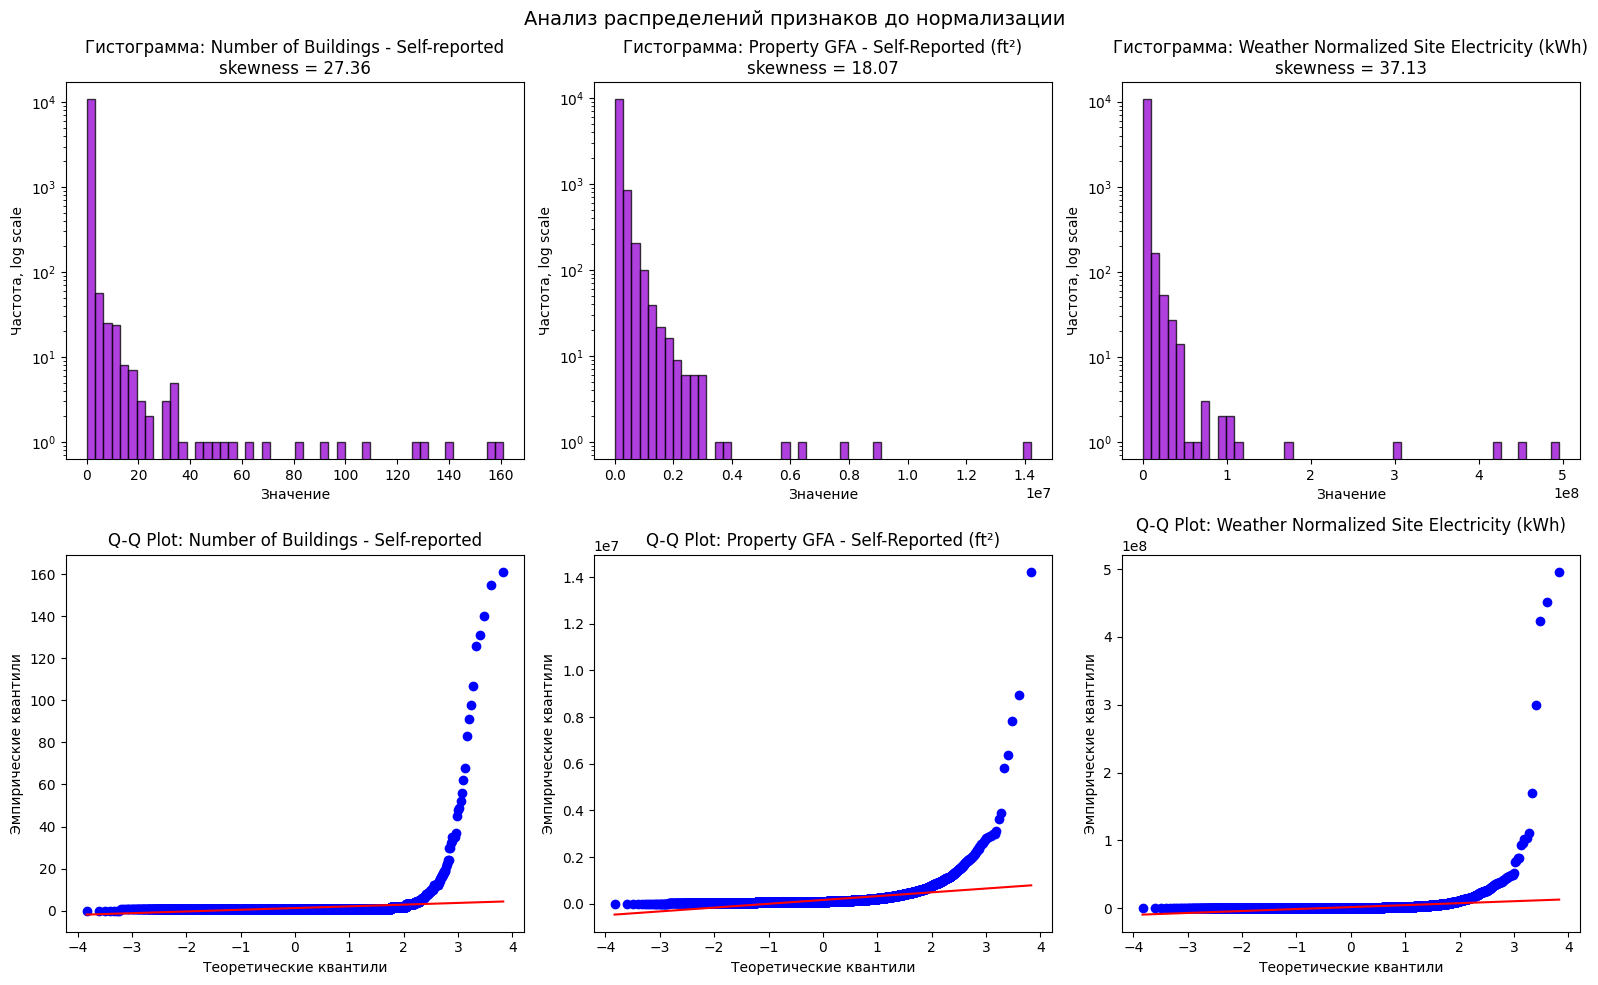

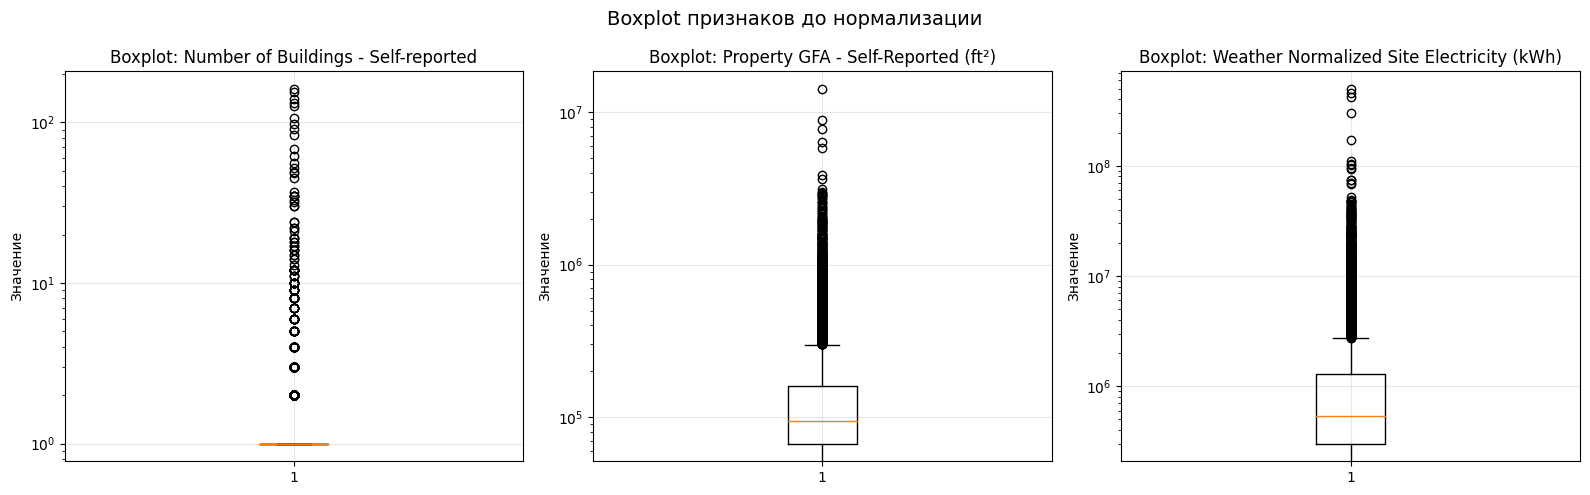


Нормализация признаков средствами sklearn

1. StandardScaler
Дает Z оценку - насколько далеко значение находится от среднего в единицах стандартного отклонения.
   Среднее после нормализации: [ 0. -0.  0.]
   Дисперсия после нормализации: [1. 1. 1.]

2. MinMaxScaler
переводит значения в диапазон от 0 до 1
   Минимум после нормализации: [0. 0. 0.]
   Максимум после нормализации: [1. 1. 1.]

3. RobustScaler
масштабирует относительно медианы и квартилей
   Медиана после нормализации: [0. 0. 0.]


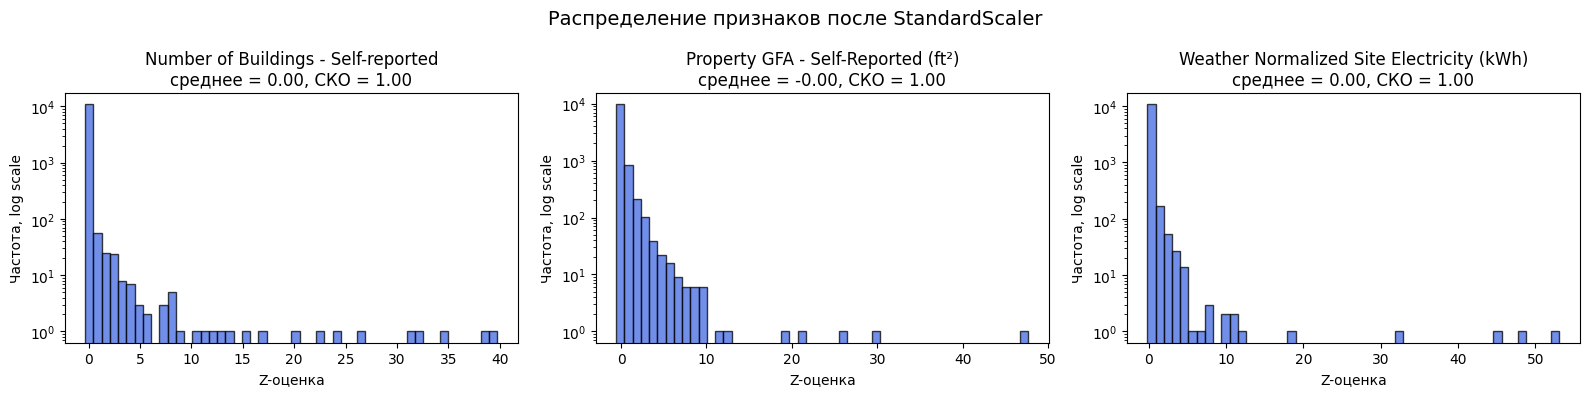

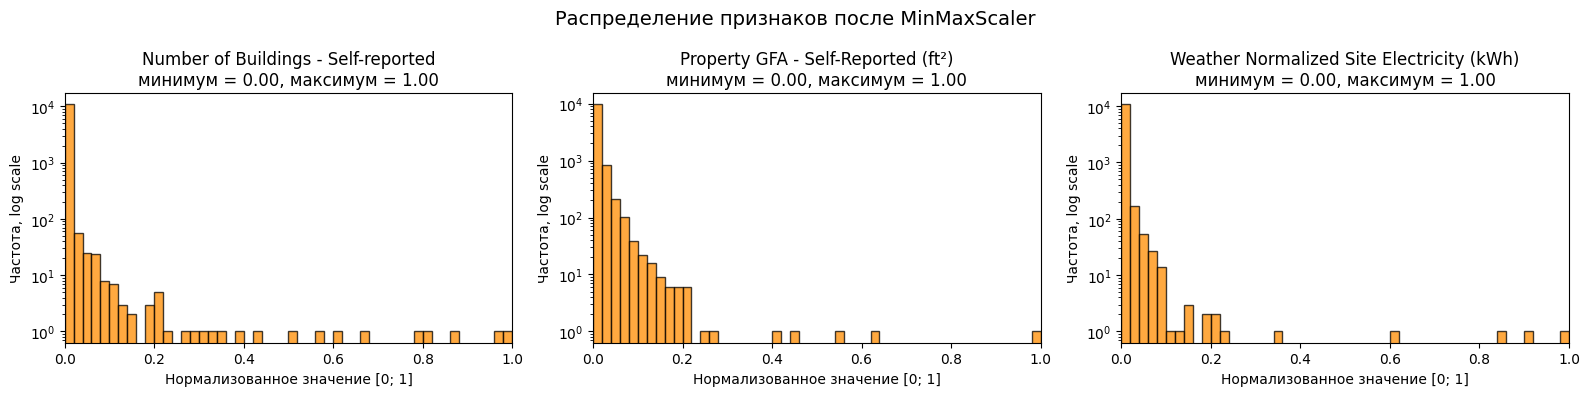

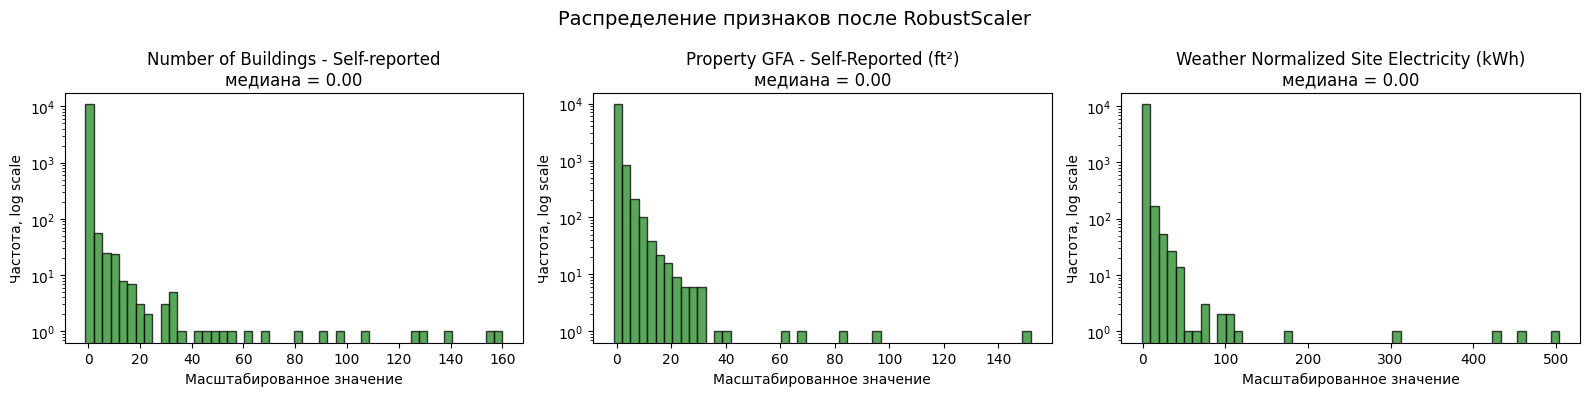

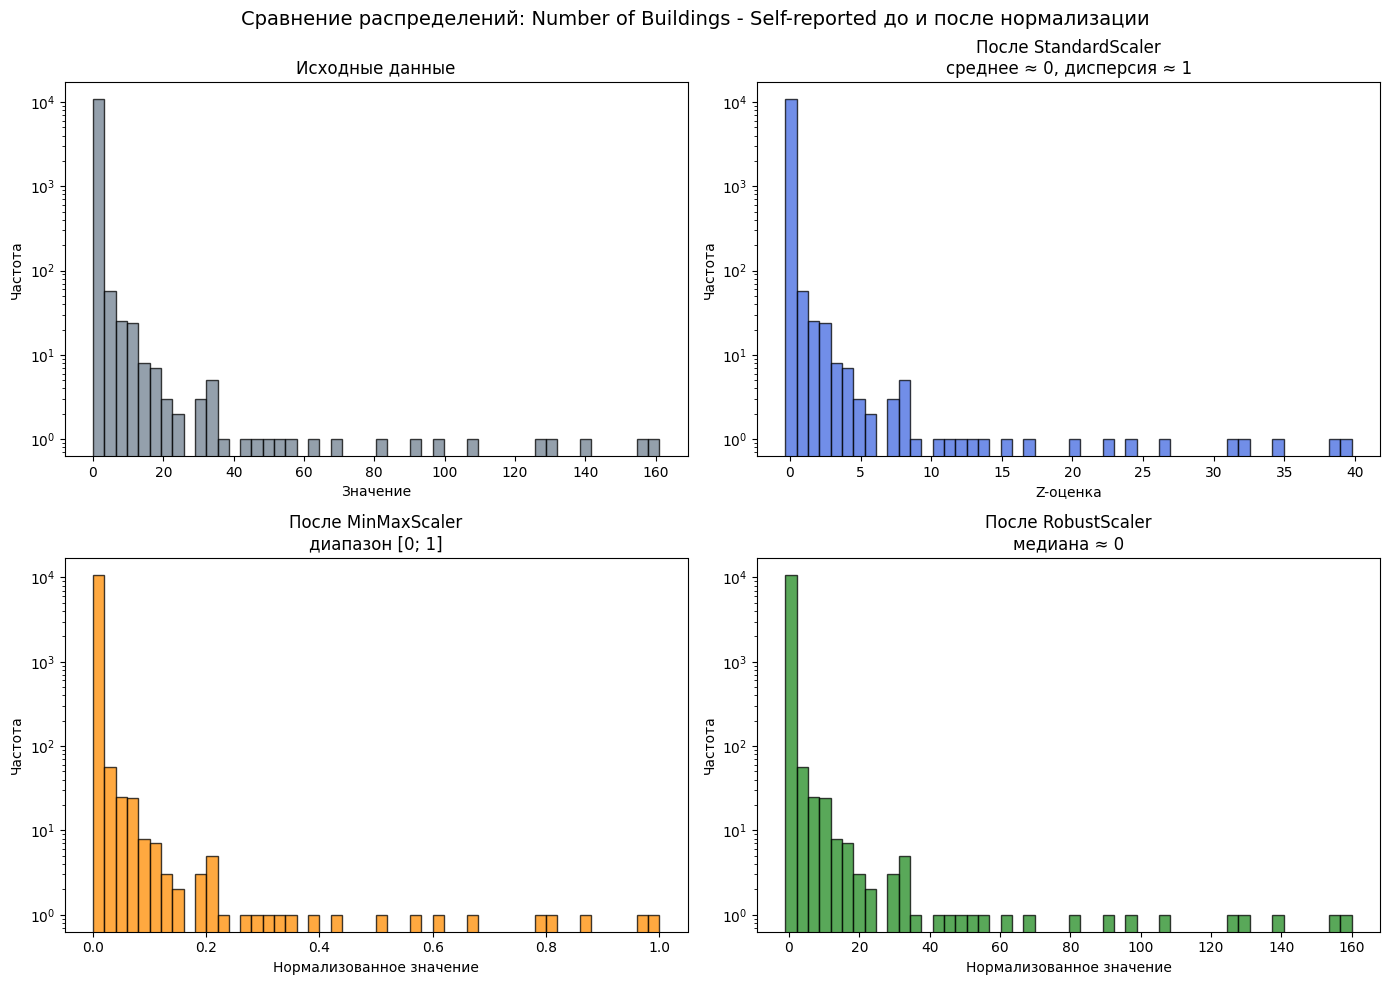

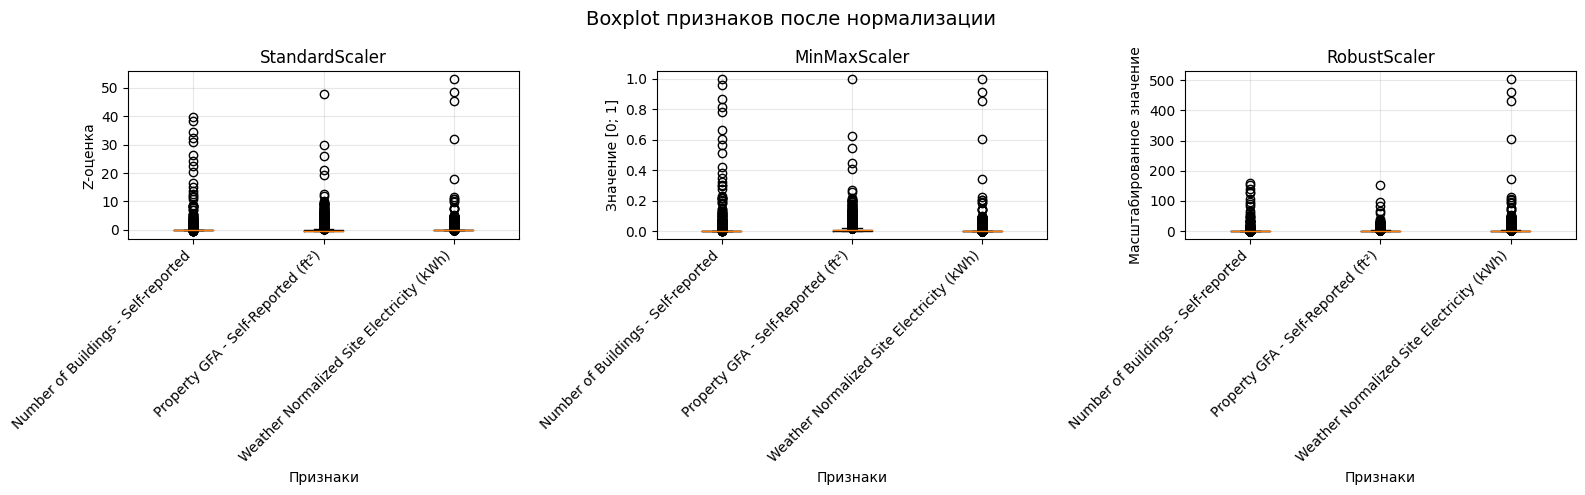


Итоговый вывод:
Были выбраны числовые признаки, связанные с характеристиками здания и энергопотреблением.
Для выбранных признаков были построены гистограммы, Q-Q plot и boxplot.
По значениям коэффициента асимметрии, тесту Шапиро-Уилка и виду графиков видно, что распределения признаков отличаются от нормального.
Это связано с сильной асимметрией, большим разбросом значений и наличием выбросов.
Метод StandardScaler привел признаки к масштабу со средним значением около 0 и дисперсией около 1.
Метод MinMaxScaler привел значения признаков к диапазону [0; 1].
Метод RobustScaler выполнил масштабирование относительно медианы.


In [38]:

pd.options.display.float_format = '{:.2f}'.format


df = pd.read_csv(
    '09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv',
    low_memory=False
)

df = df.replace('Not Available', np.nan)

target = 'Site EUI (kBtu/ft²)'

features = [
    'Number of Buildings - Self-reported',
    'Property GFA - Self-Reported (ft²)',
    'Weather Normalized Site Electricity (kWh)'
]


for col in features + [target]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')


df_clean = df.dropna(subset=features + [target]).copy()

print(f"Данные загружены: количество строк после очистки = {df_clean.shape[0]}")
print(f"Количество выбранных признаков = {len(features)}")


print("\nАнализ признаков на нормальность")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Анализ распределений признаков до нормализации', fontsize=14)

for idx, col in enumerate(features):
    column_data = df_clean[col].dropna()

    skewness = column_data.skew()

    kurtosis = column_data.kurtosis()

    if len(column_data) > 5000:
        sample_data = column_data.sample(5000, random_state=42)
    else:
        sample_data = column_data

    shapiro_stat, shapiro_p = stats.shapiro(sample_data)

    print(f"\nПризнак: {col}")
    print(f"  Среднее значение: {column_data.mean():.2f}")
    print(f"  Медиана: {column_data.median():.2f}")
    print(f"  Стандартное отклонение: {column_data.std():.2f}")
    print(f"  Коэффициент асимметрии: {skewness:.2f}")
    print(f"  Эксцесс: {kurtosis:.2f}")
    print(f"  Тест Шапиро-Уилка: p-value = {shapiro_p:.6f}")

    if skewness > 1:
        print("  Вывод: сильная правосторонняя асимметрия")
    elif skewness < -1:
        print("  Вывод: сильная левосторонняя асимметрия")
    elif abs(skewness) > 0.5:
        print("  Вывод: умеренная асимметрия")
    else:
        print("  Вывод: распределение близко к симметричному")

    if shapiro_p > 0.05:
        print("  По тесту Шапиро-Уилка распределение можно считать нормальным")
    else:
        print("  По тесту Шапиро-Уилка распределение не является нормальным")

    axes[0, idx].hist(
        column_data,
        bins=50,
        alpha=0.75,
        color='darkviolet',
        edgecolor='black'
    )
    
    axes[0, idx].set_yscale('log')
    
    axes[0, idx].set_title(f'Гистограмма: {col}\nskewness = {skewness:.2f}')
    axes[0, idx].set_xlabel('Значение')
    axes[0, idx].set_ylabel('Частота, log scale')

    stats.probplot(column_data, dist="norm", plot=axes[1, idx])
    axes[1, idx].set_title(f'Q-Q Plot: {col}')
    axes[1, idx].set_xlabel('Теоретические квантили')
    axes[1, idx].set_ylabel('Эмпирические квантили')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplot признаков до нормализации', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].boxplot(df_clean[col])
    axes[idx].set_title(f'Boxplot: {col}')
    axes[idx].set_ylabel('Значение')

    axes[idx].set_yscale('log')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\nНормализация признаков средствами sklearn")

X = df_clean[features]


scaler_std = StandardScaler()
X_standardized = scaler_std.fit_transform(X)

print("\n1. StandardScaler")
print("Дает Z оценку - насколько далеко значение находится от среднего в единицах стандартного отклонения.")
print(f"   Среднее после нормализации: {X_standardized.mean(axis=0).round(2)}")
print(f"   Дисперсия после нормализации: {X_standardized.var(axis=0).round(2)}")


scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

print("\n2. MinMaxScaler")
print("переводит значения в диапазон от 0 до 1")
print(f"   Минимум после нормализации: {X_minmax.min(axis=0).round(2)}")
print(f"   Максимум после нормализации: {X_minmax.max(axis=0).round(2)}")


scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

print("\n3. RobustScaler")
print("масштабирует относительно медианы и квартилей")
print(f"   Медиана после нормализации: {np.median(X_robust, axis=0).round(2)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Распределение признаков после StandardScaler', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].hist(
        X_standardized[:, idx],
        bins=50,
        alpha=0.75,
        color='royalblue',
        edgecolor='black'
    )
    
    axes[idx].set_yscale('log')
    
    axes[idx].set_title(
        f'{col}\nсреднее = {X_standardized[:, idx].mean():.2f}, '
        f'СКО = {X_standardized[:, idx].std():.2f}'
    )
    
    axes[idx].set_xlabel('Z-оценка')
    axes[idx].set_ylabel('Частота, log scale')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Распределение признаков после MinMaxScaler', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].hist(
        X_minmax[:, idx],
        bins=50,
        alpha=0.75,
        color='darkorange',
        edgecolor='black'
    )
    
    axes[idx].set_yscale('log')
    axes[idx].set_xlim(0, 1)
    
    axes[idx].set_title(
        f'{col}\nминимум = {X_minmax[:, idx].min():.2f}, '
        f'максимум = {X_minmax[:, idx].max():.2f}'
    )
    
    axes[idx].set_xlabel('Нормализованное значение [0; 1]')
    axes[idx].set_ylabel('Частота, log scale')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Распределение признаков после RobustScaler', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].hist(
        X_robust[:, idx],
        bins=50,
        alpha=0.75,
        color='forestgreen',
        edgecolor='black'
    )
    
    axes[idx].set_yscale('log')
    
    axes[idx].set_title(
        f'{col}\nмедиана = {np.median(X_robust[:, idx]):.2f}'
    )
    
    axes[idx].set_xlabel('Масштабированное значение')
    axes[idx].set_ylabel('Частота, log scale')

plt.tight_layout()
plt.show()


first_feature = features[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Сравнение распределений: {first_feature} до и после нормализации',
    fontsize=14
)

axes[0, 0].hist(
    df_clean[first_feature],
    bins=50,
    alpha=0.75,
    color='slategray',
    edgecolor='black'
)
axes[0, 0].set_title('Исходные данные')
axes[0, 0].set_xlabel('Значение')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_yscale('log')


axes[0, 1].hist(
    X_standardized[:, 0],
    bins=50,
    alpha=0.75,
    color='royalblue',
    edgecolor='black'
)
axes[0, 1].set_title('После StandardScaler\nсреднее ≈ 0, дисперсия ≈ 1')
axes[0, 1].set_xlabel('Z-оценка')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].set_yscale('log')

axes[1, 0].hist(
    X_minmax[:, 0],
    bins=50,
    alpha=0.75,
    color='darkorange',
    edgecolor='black'
)
axes[1, 0].set_title('После MinMaxScaler\nдиапазон [0; 1]')
axes[1, 0].set_xlabel('Нормализованное значение')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_yscale('log')

axes[1, 1].hist(
    X_robust[:, 0],
    bins=50,
    alpha=0.75,
    color='forestgreen',
    edgecolor='black'
)
axes[1, 1].set_title('После RobustScaler\nмедиана ≈ 0')
axes[1, 1].set_xlabel('Нормализованное значение')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplot признаков после нормализации', fontsize=14)

axes[0].boxplot(X_standardized)
axes[0].set_title('StandardScaler')
axes[0].set_xlabel('Признаки')
axes[0].set_ylabel('Z-оценка')
axes[0].set_xticklabels(features, rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(X_minmax)
axes[1].set_title('MinMaxScaler')
axes[1].set_xlabel('Признаки')
axes[1].set_ylabel('Значение [0; 1]')
axes[1].set_xticklabels(features, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)

axes[2].boxplot(X_robust)
axes[2].set_title('RobustScaler')
axes[2].set_xlabel('Признаки')
axes[2].set_ylabel('Масштабированное значение')
axes[2].set_xticklabels(features, rotation=45, ha='right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\nИтоговый вывод:")
print("Были выбраны числовые признаки, связанные с характеристиками здания и энергопотреблением.")
print("Для выбранных признаков были построены гистограммы, Q-Q plot и boxplot.")
print("По значениям коэффициента асимметрии, тесту Шапиро-Уилка и виду графиков видно, что распределения признаков отличаются от нормального.")
print("Это связано с сильной асимметрией, большим разбросом значений и наличием выбросов.")
print("Метод StandardScaler привел признаки к масштабу со средним значением около 0 и дисперсией около 1.")
print("Метод MinMaxScaler привел значения признаков к диапазону [0; 1].")
print("Метод RobustScaler выполнил масштабирование относительно медианы.")

#### Задание 3. Загрузить датасет проанализировать на сбалансированность, применить методы балансировки, воспользоваться встроенными методами библиотеки sklearn, сделать выводы.
**Датасет: 10_fire_dataset_bin.xlsx
данные о лесных пожарах.
Целевая переменная для балансировки - area.**

Размер датасета: (8166, 22)

Первые строки датасета:


,Unnamed: 0,area,lon,lat,Dist_str,Dist_railw,Dist_car,T,Po,P,...,DD,Ff,N,WW,Cl,Nh,H,Cm,VV,Td
0,2017-09-24 10:00:00,0,0.00,0.00,0.00,0.00,0.00,9.40,761.90,774.80,...,"Ветер, дующий с востока",2,100%.,NaN,"Слоисто-кучевые, образовавшиеся не из кучевых.",50%.,600-1000,"Высококучевые просвечивающие, расположенные на...",10.00,4.30
1,2017-09-24 13:00:00,0,0.00,0.00,0.00,0.00,0.00,11.70,762.40,775.20,...,"Ветер, дующий с северо-северо-востока",3,70 – 80%.,NaN,"Слоисто-кучевые, образовавшиеся не из кучевых.",70 – 80%.,600-1000,"Высококучевых, высокослоистых или слоисто-дожд...",10.00,3.10
2,2017-09-24 16:00:00,0,0.00,0.00,0.00,0.00,0.00,11.60,762.70,775.60,...,"Ветер, дующий с северо-востока",2,70 – 80%.,NaN,"Слоисто-кучевые, образовавшиеся не из кучевых.",70 – 80%.,600-1000,"Высококучевых, высокослоистых или слоисто-дожд...",10.00,2.30
3,2017-09-24 19:00:00,0,0.00,0.00,0.00,0.00,0.00,7.70,763.30,776.40,...,"Ветер, дующий с северо-востока",2,70 – 80%.,NaN,"Кучево-дождевые лысые с кучевыми, слоисто-куче...",70 – 80%.,600-1000,"Высококучевых, высокослоистых или слоисто-дожд...",10.00,1.20
4,2017-09-24 22:00:00,0,0.00,0.00,0.00,0.00,0.00,6.10,763.60,773.70,...,"Ветер, дующий с севера",1,Облаков нет.,NaN,"Кучево-дождевые лысые с кучевыми, слоисто-куче...",70 – 80%.,600-1000,"Высококучевых, высокослоистых или слоисто-дожд...",10.00,2.30



Распределение классов до балансировки:


,Класс,Количество объектов,"Доля, %"
0,0 — нет пожара,7744,94.83
1,1 — пожар,422,5.17


Соотношение классов: 18.35:1


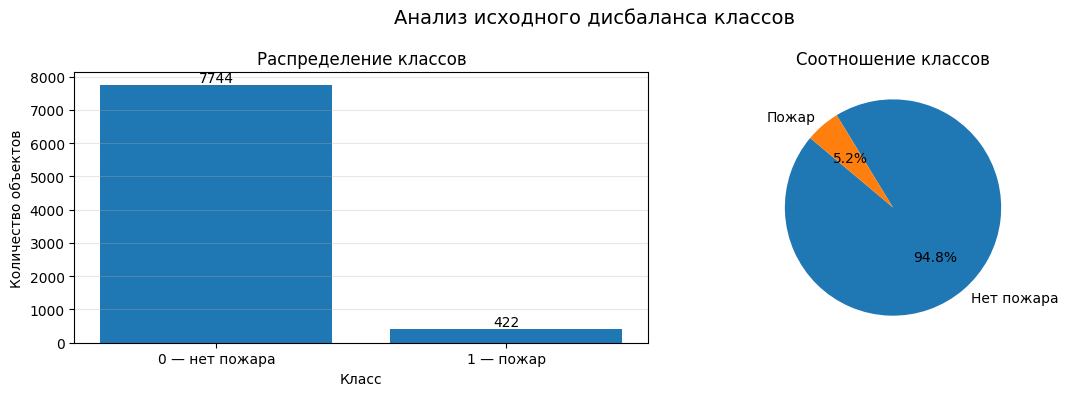


Используемые признаки:
['lon', 'lat', 'Dist_str', 'Dist_railw', 'Dist_car', 'T', 'Po', 'P', 'Pa', 'U', 'Ff', 'VV', 'Td']

Размер X: (8166, 13)
Размер y: (8166,)


NameError: name 'RandomUnderSampler' is not defined

In [39]:
file_path = "10_fire_dataset_bin.xlsx"

df = pd.read_excel(file_path, sheet_name="fire_dataset_bin")

print(f"Размер датасета: {df.shape}")
print("\nПервые строки датасета:")
display(df.head())


df["target"] = (df["area"] > 0).astype(int)

class_counts = df["target"].value_counts().sort_index()
class_percent = df["target"].value_counts(normalize=True).sort_index() * 100

balance_table = pd.DataFrame({
    "Класс": ["0 — нет пожара", "1 — пожар"],
    "Количество объектов": class_counts.values,
    "Доля, %": class_percent.round(2).values
})

print("\nРаспределение классов до балансировки:")
display(balance_table)

print(f"Соотношение классов: {class_counts[0] / class_counts[1]:.2f}:1")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Анализ исходного дисбаланса классов", fontsize=14)

axes[0].bar(["0 — нет пожара", "1 — пожар"], class_counts.values)
axes[0].set_title("Распределение классов")
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Количество объектов")
axes[0].grid(axis="y", alpha=0.3)

for i, value in enumerate(class_counts.values):
    axes[0].text(i, value, str(value), ha="center", va="bottom")

axes[1].pie(
    class_counts.values,
    labels=["Нет пожара", "Пожар"],
    autopct="%1.1f%%",
    startangle=140
)

axes[1].set_title("Соотношение классов")

plt.tight_layout()
plt.show()


numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

exclude_cols = ["area", "target"]

feature_cols = [col for col in numeric_cols if col not in exclude_cols]

X = df[feature_cols].copy()
y = df["target"].copy()

data = pd.concat([X, y], axis=1).dropna()

X = data.drop(columns=["target"]).reset_index(drop=True)
y = data["target"].reset_index(drop=True)

print("\nИспользуемые признаки:")
print(feature_cols)

print(f"\nРазмер X: {X.shape}")
print(f"Размер y: {y.shape}")

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)


methods = {
    "Исходные данные": None,
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss v1": NearMiss(version=1),
    "NearMiss v2": NearMiss(version=2),
    "NearMiss v3": NearMiss(version=3),
    "RandomOverSampler": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42)
}


datasets_scaled = {}
datasets_plot = {}
results = {}

for name, method in methods.items():

    if method is None:
        X_res_scaled = X_scaled.copy()
        y_resampled = y.copy()

    else:
        X_res_scaled, y_resampled = method.fit_resample(X_scaled, y)

        X_res_scaled = pd.DataFrame(
            X_res_scaled,
            columns=X_scaled.columns
        )

        y_resampled = pd.Series(y_resampled, name="target")

    X_res_scaled = X_res_scaled.reset_index(drop=True)
    y_resampled = y_resampled.reset_index(drop=True)

    datasets_scaled[name] = (X_res_scaled, y_resampled)

    X_res_plot = pd.DataFrame(
        scaler.inverse_transform(X_res_scaled),
        columns=X.columns
    )

    datasets_plot[name] = (X_res_plot, y_resampled)

    results[name] = Counter(y_resampled)

    print(f"{name}: {results[name]} (всего: {len(y_resampled)})")


comparison = pd.DataFrame({
    "Метод": list(results.keys()),
    "Класс 0 — нет пожара": [results[name].get(0, 0) for name in results],
    "Класс 1 — пожар": [results[name].get(1, 0) for name in results],
    "Всего объектов": [sum(results[name].values()) for name in results]
})

print("\nСравнение распределения классов:")
display(comparison)


fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

fig.suptitle("Сравнение распределения классов до и после балансировки", fontsize=16)

for i, (name, counts) in enumerate(results.items()):
    values = [counts.get(0, 0), counts.get(1, 0)]

    axes[i].bar(["Нет пожара", "Пожар"], values)
    axes[i].set_title(name, fontsize=11)
    axes[i].set_ylabel("Количество объектов")
    axes[i].grid(axis="y", alpha=0.3)

    for j, value in enumerate(values):
        axes[i].text(j, value, str(value), ha="center", va="bottom", fontsize=9)

for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


col_x = "T"
col_y = "U"

print(f"\nДля диаграмм рассеивания выбраны признаки: {col_x} и {col_y}")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

fig.suptitle(f"Диаграммы рассеивания: {col_x} vs {col_y}", fontsize=16)

for i, (name, (X_data, y_data)) in enumerate(datasets_plot.items()):

    counter = Counter(y_data)

    for label, _ in counter.items():
        row_ix = np.where(y_data == label)[0]

        if label == 0:
            class_name = "Нет пожара"
            color = "royalblue"
            alpha = 0.45
        else:
            class_name = "Пожар"
            color = "crimson"
            alpha = 0.65

        axes[i].scatter(
            X_data.iloc[row_ix][col_x],
            X_data.iloc[row_ix][col_y],
            label=class_name,
            color=color,
            alpha=alpha,
            s=18
        )

    axes[i].set_title(f"{name}\nN = {len(y_data)}", fontsize=11)
    axes[i].set_xlabel(col_x, fontsize=10)
    axes[i].set_ylabel(col_y, fontsize=10)
    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=8)

for j in range(len(datasets_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

fig.suptitle("Соотношение классов до и после балансировки", fontsize=16)

for i, (name, counts) in enumerate(results.items()):
    values = [counts.get(0, 0), counts.get(1, 0)]

    axes[i].pie(
        values,
        labels=["Нет пожара", "Пожар"],
        autopct="%1.1f%%",
        startangle=140
    )

    axes[i].set_title(f"{name}\nN = {sum(values)}", fontsize=11)

for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Задание 4. Загрузить датасет проанализировать на наличие аномалий и выбросов, сделать визуализацию, сделать выводы.  
**Датасет: 10_fire_dataset_bin.xlsx
данные о лесных пожарах.
Целевая переменная – area**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


pd.options.display.float_format = '{:.2f}'.format

data = pd.read_excel('10_fire_dataset_bin.xlsx')

target = 'area'

print('Датасет загружен')
print('Размер датасета:', data.shape)

display(data.head())

print('\nИнформация о датасете:')
data.info()

print('\nКоличество пропусков:')
print(data.isnull().sum())


# Удаляем строки, где отсутствует целевая переменная
data = data.dropna(subset=[target]).copy()


# Анализ целевой переменной area
print('\nРаспределение целевой переменной area:')
area_counts = data[target].value_counts().sort_index()
print(area_counts)

plt.figure(figsize=(6, 6))

plt.pie(
    area_counts.values,
    labels=area_counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Распределение целевой переменной area')
plt.show()


if data[target].nunique() <= 2:
    print('\nЦелевая переменная area является бинарной.')
    print('Поэтому выбросы в area как в обычном числовом признаке не анализируются.')
else:
    area_data = data[target].dropna()

    q1 = area_data.quantile(0.25)
    q3 = area_data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    area_outliers = area_data[
        (area_data < lower_bound) | (area_data > upper_bound)
    ]

    print('\nАнализ выбросов целевой переменной area методом IQR:')
    print(f'Q1: {q1:.2f}')
    print(f'Q3: {q3:.2f}')
    print(f'IQR: {iqr:.2f}')
    print(f'Нижняя граница: {lower_bound:.2f}')
    print(f'Верхняя граница: {upper_bound:.2f}')
    print(f'Количество выбросов area: {len(area_outliers)}')

    plt.figure(figsize=(6, 5))
    plt.boxplot(
        area_data,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        whiskerprops=dict(color='navy'),
        capprops=dict(color='navy'),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(
            marker='o',
            markerfacecolor='darkorange',
            markeredgecolor='black',
            markersize=5,
            alpha=0.6
        )
    )

    plt.title('Boxplot целевой переменной area')
    plt.ylabel('area')
    plt.grid(True, alpha=0.3)
    plt.show()


# Выбираем числовые признаки
numeric_cols = data.select_dtypes(include='number').columns.tolist()

# Для анализа выбросов берем числовые признаки, кроме целевой переменной
feature_cols = [col for col in numeric_cols if col != target]

print('\nЧисловые признаки для анализа выбросов:')
print(feature_cols)


print('\nОписательная статистика числовых признаков:')
display(data[feature_cols].describe().round(2))


# Таблица перцентилей
percentile_summary = {}

for col in feature_cols:
    col_data = data[col].dropna()

    if len(col_data) == 0:
        continue

    percentile_summary[col] = {
        'min': col_data.min(),
        '25%': col_data.quantile(0.25),
        '50%': col_data.quantile(0.50),
        '75%': col_data.quantile(0.75),
        '95%': col_data.quantile(0.95),
        '99%': col_data.quantile(0.99),
        'max': col_data.max()
    }

percentile_df = pd.DataFrame(percentile_summary).T

print('\nПерцентили числовых признаков:')
display(percentile_df.round(2))


# Поиск выбросов методом IQR и Z-score
outliers_summary = {}

for col in feature_cols:
    col_data = data[col].dropna()

    if len(col_data) == 0 or col_data.nunique() <= 1:
        continue

    q1 = col_data.quantile(0.25)
    q3 = col_data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_iqr = col_data[
        (col_data < lower_bound) | (col_data > upper_bound)
    ]

    z_scores = np.abs(stats.zscore(col_data))
    outliers_z = col_data[z_scores > 3]

    outliers_summary[col] = {
        'min': col_data.min(),
        'max': col_data.max(),
        'mean': col_data.mean(),
        'median': col_data.median(),
        'std': col_data.std(),
        'IQR_outliers_count': len(outliers_iqr),
        'IQR_outliers_percent': len(outliers_iqr) / len(col_data) * 100,
        'Z_outliers_count': len(outliers_z),
        'Z_outliers_percent': len(outliers_z) / len(col_data) * 100
    }

outliers_df = pd.DataFrame(outliers_summary).T

print('\nСводка выбросов по числовым признакам:')
display(outliers_df.round(2))


# Столбчатая диаграмма количества выбросов по IQR
iqr_counts = outliers_df['IQR_outliers_count'].sort_values(ascending=False)

plt.figure(figsize=(12, 5))

bars = plt.bar(
    iqr_counts.index,
    iqr_counts.values,
    color='darkorange',
    edgecolor='black'
)

plt.title('Количество выбросов по признакам методом IQR')
plt.xlabel('Признак')
plt.ylabel('Количество выбросов')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Boxplot признаков с наибольшим количеством выбросов
selected_cols = iqr_counts.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    col_data = data[col].dropna()

    axes[i].boxplot(
        col_data,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        whiskerprops=dict(color='navy'),
        capprops=dict(color='navy'),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(
            marker='o',
            markerfacecolor='darkorange',
            markeredgecolor='black',
            markersize=5,
            alpha=0.6
        )
    )

    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel('Значение')
    axes[i].set_xticklabels([col])
    axes[i].grid(True, alpha=0.3)

for j in range(len(selected_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Boxplot признаков с наибольшим количеством выбросов', fontsize=14)
plt.tight_layout()
plt.show()


# Определяем строки, где есть выброс хотя бы по одному признаку
data_iqr = data.copy()
data_iqr['IQR_Outlier'] = False

for col in feature_cols:
    col_data = data_iqr[col].dropna()

    if len(col_data) == 0 or col_data.nunique() <= 1:
        continue

    q1 = data_iqr[col].quantile(0.25)
    q3 = data_iqr[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    data_iqr['IQR_Outlier'] = data_iqr['IQR_Outlier'] | (
        (data_iqr[col] < lower_bound) | (data_iqr[col] > upper_bound)
    )

iqr_outlier_counts = data_iqr['IQR_Outlier'].value_counts()

print('\nКоличество строк с выбросами хотя бы по одному признаку:')
print(iqr_outlier_counts)


plt.figure(figsize=(6, 6))

plt.pie(
    iqr_outlier_counts.values,
    labels=['Без выбросов', 'С выбросами'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#55A868', '#C44E52'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Доля строк с выбросами по методу IQR')
plt.show()


# Корреляционная матрица
corr_data = data[feature_cols + [target]].copy()
corr_matrix = corr_data.corr()

print('\nКорреляционная матрица:')
display(corr_matrix.round(2))

plt.figure(figsize=(10, 8))

plt.imshow(
    corr_matrix,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Коэффициент корреляции')

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f'{corr_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center',
            fontsize=9
        )

plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()


# Корреляция признаков с целевой переменной area
corr_with_area = corr_matrix[target].drop(target).sort_values(ascending=False)

print('\nКорреляция признаков с целевой переменной area:')
display(corr_with_area.round(2))

plt.figure(figsize=(10, 5))

bars = plt.bar(
    corr_with_area.index,
    corr_with_area.values,
    color='steelblue',
    edgecolor='black'
)

plt.title('Корреляция признаков с целевой переменной area')
plt.xlabel('Признак')
plt.ylabel('Коэффициент корреляции')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom' if height >= 0 else 'top'
    )

plt.tight_layout()
plt.show()


# Поиск аномалий методом IsolationForest
X = data[feature_cols].copy()

# Заполняем возможные пропуски медианой
X = X.fillna(X.median())

# Масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# contamination=0.05 означает, что ожидаем примерно 5% аномалий
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

data['anomaly'] = model.fit_predict(X_scaled)

# В sklearn: 1 — нормальный объект, -1 — аномалия
data['anomaly'] = data['anomaly'].map({
    1: 'Норма',
    -1: 'Аномалия'
})

anomaly_counts = data['anomaly'].value_counts()

print('\nРезультат поиска аномалий методом IsolationForest:')
print(anomaly_counts)


plt.figure(figsize=(6, 6))

plt.pie(
    anomaly_counts.values,
    labels=anomaly_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Доля аномалий по методу IsolationForest')
plt.show()


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'anomaly': data['anomaly']
})

colors = pca_df['anomaly'].map({
    'Норма': '#4C72B0',
    'Аномалия': '#C44E52'
})

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=colors,
    alpha=0.7,
    edgecolors='black'
)

plt.title('Визуализация аномалий после PCA')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.grid(True, alpha=0.3)

plt.show()


print('\nВыводы:')
print('Был выполнен анализ датасета лесных пожаров на наличие выбросов и аномалий.')
print('Выбросы — это отдельные значения признаков, которые сильно отличаются от основной массы данных.')
print('Аномалии — это строки датасета, которые являются нетипичными по совокупности нескольких признаков.')
print('Для поиска выбросов использовались метод IQR и метод Z-score.')
print('Таблица перцентилей показала, насколько крайние значения отличаются от основной массы данных.')
print('Boxplot-графики показали наличие экстремальных значений в отдельных признаках.')
print('Столбчатая диаграмма позволила сравнить количество выбросов по разным признакам.')
print('Корреляционная матрица была построена для анализа взаимосвязей между числовыми признаками.')
print('Корреляция с area показала, какие признаки сильнее связаны с целевой переменной.')
print('Метод IsolationForest был использован для поиска аномальных объектов по совокупности признаков.')
print('PCA-график использовался для визуализации аномалий в двумерном пространстве.')
print('Метод IQR анализирует признаки по отдельности, а IsolationForest оценивает объект целиком.')
print('Целевая переменная area была рассмотрена отдельно. Если она бинарная, то она является классом, а не обычным числовым признаком для поиска выбросов.')

#### Задание 5. Выполнить парсинг двух страниц с сайта https://zakupki.gov.ru/ (либо другой сайт)  по каждой закупке спарсить номер закупки, дату размещения, обновления и окончание подачи заявок, начальную цену контракта. Данные сохранить в pandas датафрейм и в формат csv.

In [29]:
import requests

from bs4 import BeautifulSoup
from datetime import datetime, timedelta


def parse_laptops_page(page_num):
    url = f'https://webscraper.io/test-sites/e-commerce/static/computers/laptops?page={page_num}'
    
    response = requests.get(url)
    response.raise_for_status()
    
    soup = BeautifulSoup(response.text, 'html.parser')
    
    laptops = []
    
    for laptop in soup.find_all('div', class_='card thumbnail'):
        title_tag = laptop.find('a', class_='title')
        price_tag = laptop.find('h4', class_='price')
        description_tag = laptop.find('p', class_='description')
        reviews_tag = laptop.find('p', class_='review-count')
        
        title = title_tag.text.strip() if title_tag else 'Нет названия'
        price = price_tag.text.strip() if price_tag else 'Нет цены'
        description = description_tag.text.strip() if description_tag else 'Нет описания'
        reviews = reviews_tag.text.strip() if reviews_tag else 'Нет отзывов'
        
        publish_date = datetime(2024, 3, 1) + timedelta(days=page_num)
        update_date = publish_date + timedelta(days=5)
        submission_deadline = publish_date + timedelta(days=15)
        
        purchase = {
            'purchase_number': f'LAPTOP-{page_num}-{len(laptops) + 1}',
            'product_name': title,
            'contract_price': price,
            'description': description,
            'reviews': reviews,
            'publish_date': publish_date.strftime('%Y-%m-%d'),
            'update_date': update_date.strftime('%Y-%m-%d'),
            'submission_deadline': submission_deadline.strftime('%Y-%m-%d')
        }
        
        laptops.append(purchase)
    
    return laptops


all_data = []

for page in [1, 2, 3]:
    print(f'\nПарсинг страницы {page}')
    
    page_data = parse_laptops_page(page)
    all_data.extend(page_data)
    
    print(f'  Найдено записей: {len(page_data)}')


df = pd.DataFrame(all_data)

df.columns = [
    'Номер закупки',
    'Наименование товара',
    'Начальная цена контракта',
    'Описание',
    'Количество отзывов',
    'Дата размещения',
    'Дата обновления',
    'Окончание подачи заявок'
]

print(f'\nВсего собрано: {len(df)} записей')
display(df.head())

df.to_csv(
    'parsed_laptop_purchases.csv',
    index=False,
    encoding='utf-8-sig'
)

print('\nФайл parsed_laptop_purchases.csv сохранен')

print('\nСтатистика')
print(f'Всего: {len(df)}')
print(f'Уникальных товаров: {df["Наименование товара"].nunique()}')
print(f'Диапазон цен: от {df["Начальная цена контракта"].min()} до {df["Начальная цена контракта"].max()}')

print('\nРаспределение по количеству отзывов:')
print(df['Количество отзывов'].value_counts())


Парсинг страницы 1
  Найдено записей: 6

Парсинг страницы 2
  Найдено записей: 6

Парсинг страницы 3
  Найдено записей: 6

Всего собрано: 18 записей


,Номер закупки,Наименование товара,Начальная цена контракта,Описание,Количество отзывов,Дата размещения,Дата обновления,Окончание подачи заявок
0,LAPTOP-1-1,Packard 255 G2,$416.99,"15.6"", AMD E2-3800 1.3GHz, 4GB, 500GB, Windows...",2 reviews,2024-03-02,2024-03-07,2024-03-17
1,LAPTOP-1-2,Aspire E1-510,$306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux",2 reviews,2024-03-02,2024-03-07,2024-03-17
2,LAPTOP-1-3,ThinkPad T540p,$1178.99,"15.6"", Core i5-4200M, 4GB, 500GB, Win7 Pro 64bit",2 reviews,2024-03-02,2024-03-07,2024-03-17
3,LAPTOP-1-4,ProBook,$739.99,"14"", Core i5 2.6GHz, 4GB, 500GB, Win7 Pro 64bit",8 reviews,2024-03-02,2024-03-07,2024-03-17
4,LAPTOP-1-5,ThinkPad X240,$1311.99,"12.5"", Core i5-4300U, 8GB, 240GB SSD, Win7 Pro...",12 reviews,2024-03-02,2024-03-07,2024-03-17



Файл parsed_laptop_purchases.csv сохранен

Статистика
Всего: 18
Уникальных товаров: 17
Диапазон цен: от $1033.99 до $745.99

Распределение по количеству отзывов:
Количество отзывов
2 reviews     5
4 reviews     3
12 reviews    2
13 reviews    2
10 reviews    2
8 reviews     1
14 reviews    1
0 reviews     1
9 reviews     1
Name: count, dtype: int64


#### Задание 6. Загрузить и собрать датасет, определить категориальные признаки, применить методы LabelEncoder, One Hot Encoding, написать выводы.
**Датасет: 11_automobiles.rar
Описывает классические автомобили**

In [30]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

columns = [
    'symboling',
    'normalized-losses',
    'make',
    'fuel-type',
    'aspiration',
    'num-of-doors',
    'body-style',
    'drive-wheels',
    'engine-location',
    'wheel-base',
    'length',
    'width',
    'height',
    'curb-weight',
    'engine-type',
    'num-of-cylinders',
    'engine-size',
    'fuel-system',
    'bore',
    'stroke',
    'compression-ratio',
    'horsepower',
    'peak-rpm',
    'city-mpg',
    'highway-mpg',
    'price'
]

data = pd.read_csv(
    './11_automobiles/imports-85.data',
    names=columns,
    na_values='?'
)

print('Датасет загружен')
print(f'Количество строк: {data.shape[0]}')
print(f'Количество столбцов: {data.shape[1]}')

numeric_cols_to_convert = [
    'normalized-losses',
    'bore',
    'stroke',
    'horsepower',
    'peak-rpm',
    'price'
]

for col in numeric_cols_to_convert:
    data[col] = pd.to_numeric(data[col], errors='coerce')


numeric_cols = data.select_dtypes(include='number').columns.tolist()

categorical_cols = [
    col for col in data.columns
    if pd.api.types.is_object_dtype(data[col]) or pd.api.types.is_string_dtype(data[col])
]

print('\nЧисловые признаки:')
for col in numeric_cols:
    print(f'- {col}')

print('\nКатегориальные признаки:')
for col in categorical_cols:
    print(f'- {col}')


print('\nКоличество уникальных значений в категориальных признаках:')
for col in categorical_cols:
    print(f'{col}: {data[col].nunique()} уникальных значений')


print('\nПримеры значений категориальных признаков до кодирования:')
for col in categorical_cols:
    unique_values = data[col].dropna().unique()[:10]
    print(f'{col}: {list(unique_values)}')


data_prepared = data.copy()

for col in numeric_cols:
    if data_prepared[col].isnull().sum() > 0:
        median_value = data_prepared[col].median()
        missing_count = data_prepared[col].isnull().sum()

        data_prepared[col] = data_prepared[col].fillna(median_value)

for col in categorical_cols:
    if data_prepared[col].isnull().sum() > 0:
        mode_value = data_prepared[col].mode()[0]
        missing_count = data_prepared[col].isnull().sum()

        data_prepared[col] = data_prepared[col].fillna(mode_value)

data_label_encoded = data_prepared.copy()

label_encoders = {}

display_cols = ['make', 'fuel-type']

print('\nLabelEncoder: как было и как стало')

for col in categorical_cols:
    encoder = LabelEncoder()

    old_values = data_label_encoded[col].copy()
    data_label_encoded[col] = encoder.fit_transform(data_label_encoded[col])

    label_encoders[col] = encoder

    if col in display_cols:
        print(f'\nПризнак: {col}')

        mapping = pd.DataFrame({
            'Категория': encoder.classes_,
            'Код': range(len(encoder.classes_))
        })

        print('Соответствие категорий и кодов:')
        display(mapping)



print('\nРазмеры датасета:')
print(f'До LabelEncoder: {data_prepared.shape}')
print(f'После LabelEncoder: {data_label_encoded.shape}')
data_one_hot = data_prepared.copy()

try:
    one_hot_encoder = OneHotEncoder(
        sparse_output=False,
        handle_unknown='ignore'
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        sparse=False,
        handle_unknown='ignore'
    )

encoded_array = one_hot_encoder.fit_transform(data_one_hot[categorical_cols])
encoded_columns = one_hot_encoder.get_feature_names_out(categorical_cols)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_columns,
    index=data_one_hot.index
)

data_without_categorical = data_one_hot.drop(columns=categorical_cols)

data_one_hot_encoded = pd.concat(
    [data_without_categorical, encoded_df],
    axis=1
)


print('\nOne Hot Encoding: как было и как стало')

print(f'Количество категориальных признаков до One Hot Encoding: {len(categorical_cols)}')
print(f'Количество новых бинарных признаков после One Hot Encoding: {len(encoded_columns)}')

print('\nИсходные категориальные признаки:')
print(categorical_cols)

print('\nПервые 30 новых one-hot признаков:')
print(list(encoded_columns[:30]))


print('\nСравнение размеров:')
print(f'До One Hot Encoding: {data_prepared.shape}')
print(f'После One Hot Encoding: {data_one_hot_encoded.shape}')


comparison = pd.DataFrame({
    'Вариант': [
        'Исходный датасет',
        'После обработки пропусков',
        'После LabelEncoder',
        'После One Hot Encoding'
    ],
    'Количество строк': [
        data.shape[0],
        data_prepared.shape[0],
        data_label_encoded.shape[0],
        data_one_hot_encoded.shape[0]
    ],
    'Количество столбцов': [
        data.shape[1],
        data_prepared.shape[1],
        data_label_encoded.shape[1],
        data_one_hot_encoded.shape[1]
    ]
})

print('\nИтоговое сравнение размеров датасетов:')
display(comparison)


data_label_encoded.to_csv(
    'automobiles_label_encoded.csv',
    index=False,
    encoding='utf-8-sig'
)

data_one_hot_encoded.to_csv(
    'automobiles_one_hot_encoded.csv',
    index=False,
    encoding='utf-8-sig'
)

print('\nФайлы сохранены:')
print('automobiles_label_encoded.csv')
print('automobiles_one_hot_encoded.csv')


print('\nВыводы:')
print('Для категориальных признаков был применен LabelEncoder.')
print('После LabelEncoder категориальные значения были заменены числовыми кодами.')
print('Недостаток LabelEncoder в том, что он может создать искусственный порядок между категориями.')
print('Также был применен One Hot Encoding.')
print('После One Hot Encoding каждая категория была преобразована в отдельный бинарный признак.')
print('Количество столбцов после One Hot Encoding увеличилось.')

Датасет загружен
Количество строк: 205
Количество столбцов: 26

Числовые признаки:
- symboling
- normalized-losses
- wheel-base
- length
- width
- height
- curb-weight
- engine-size
- bore
- stroke
- compression-ratio
- horsepower
- peak-rpm
- city-mpg
- highway-mpg
- price

Категориальные признаки:
- make
- fuel-type
- aspiration
- num-of-doors
- body-style
- drive-wheels
- engine-location
- engine-type
- num-of-cylinders
- fuel-system

Количество уникальных значений в категориальных признаках:
make: 22 уникальных значений
fuel-type: 2 уникальных значений
aspiration: 2 уникальных значений
num-of-doors: 2 уникальных значений
body-style: 5 уникальных значений
drive-wheels: 3 уникальных значений
engine-location: 2 уникальных значений
engine-type: 7 уникальных значений
num-of-cylinders: 7 уникальных значений
fuel-system: 8 уникальных значений

Примеры значений категориальных признаков до кодирования:
make: ['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'm

,Категория,Код
0,alfa-romero,0
1,audi,1
2,bmw,2
3,chevrolet,3
4,dodge,4
5,honda,5
6,isuzu,6
7,jaguar,7
8,mazda,8
9,mercedes-benz,9



Признак: fuel-type
Соответствие категорий и кодов:


,Категория,Код
0,diesel,0
1,gas,1



Размеры датасета:
До LabelEncoder: (205, 26)
После LabelEncoder: (205, 26)

One Hot Encoding: как было и как стало
Количество категориальных признаков до One Hot Encoding: 10
Количество новых бинарных признаков после One Hot Encoding: 60

Исходные категориальные признаки:
['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']

Первые 30 новых one-hot признаков:
['make_alfa-romero', 'make_audi', 'make_bmw', 'make_chevrolet', 'make_dodge', 'make_honda', 'make_isuzu', 'make_jaguar', 'make_mazda', 'make_mercedes-benz', 'make_mercury', 'make_mitsubishi', 'make_nissan', 'make_peugot', 'make_plymouth', 'make_porsche', 'make_renault', 'make_saab', 'make_subaru', 'make_toyota', 'make_volkswagen', 'make_volvo', 'fuel-type_diesel', 'fuel-type_gas', 'aspiration_std', 'aspiration_turbo', 'num-of-doors_four', 'num-of-doors_two', 'body-style_convertible', 'body-style_hardtop']

Сравнение размеров:
До One 

,Вариант,Количество строк,Количество столбцов
0,Исходный датасет,205,26
1,После обработки пропусков,205,26
2,После LabelEncoder,205,26
3,После One Hot Encoding,205,76



Файлы сохранены:
automobiles_label_encoded.csv
automobiles_one_hot_encoded.csv

Выводы:
Для категориальных признаков был применен LabelEncoder.
После LabelEncoder категориальные значения были заменены числовыми кодами.
Недостаток LabelEncoder в том, что он может создать искусственный порядок между категориями.
Также был применен One Hot Encoding.
После One Hot Encoding каждая категория была преобразована в отдельный бинарный признак.
Количество столбцов после One Hot Encoding увеличилось.
